# Data Analysis Project: Experience and Salary Relationship

Import necessary libraries and setting plot style

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for our plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

Task 1: Load and Explore the Dataset

In [4]:
print("Task 1: Loading and Exploring the Dataset")

# Load the dataset
try:
    # Assuming the data is in a CSV file named 'Salary_Data.csv'
    df = pd.read_csv('Salary_Data.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please ensure the dataset file is in the correct location.")
    # Create a sample dataset based on the provided information if file is not found
    data = {
        'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 
                           4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
        'Salary': [39343.00, 46205.00, 37731.00, 43525.00, 39891.00, 56642.00, 60150.00, 54445.00, 
                  64445.00, 57189.00, 63218.00, 55794.00, 56957.00, 57081.00, 61111.00, 67938.00, 
                  66029.00, 83088.00, 81363.00, 93940.00, 91738.00, 98273.00, 101302.00, 113812.00, 
                  109431.00, 105582.00, 116969.00, 112635.00, 122391.00, 121872.00]
    }
    df = pd.DataFrame(data)
    print("Created sample dataset based on the provided information.")

# Display the first few rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check the structure of the dataset
print("\nDataset information:")
print(df.info())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Cleaning the dataset (not needed as there are no missing values in this dataset)
print("\nThe dataset doesn't have any missing values, so no cleaning is required.")


Task 1: Loading and Exploring the Dataset
Dataset loaded successfully!

First 5 rows of the dataset:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None

Missing values in each column:
YearsExperience    0
Salary             0
dtype: int64

The dataset doesn't have any missing values, so no cleaning is required.


Task 2: Basic Data Analysis

In [8]:
print("\nTask 2: Basic Data Analysis")

# Compute basic statistics for the dataset
print("\nBasic statistics of the dataset:")
print(df.describe())

# Create experience level categories for grouping
df['ExperienceLevel'] = pd.cut(df['YearsExperience'], 
                               bins=[0, 2, 5, 8, 11], 
                               labels=['Entry Level (0-2 yrs)', 
                                       'Mid Level (2-5 yrs)', 
                                       'Senior Level (5-8 yrs)', 
                                       'Expert Level (8-11 yrs)'])

# Group by experience level and compute statistics
grouped_stats = df.groupby('ExperienceLevel', observed=True)['Salary'].agg(['mean', 'median', 'std', 'count'])
print("\nSalary statistics by experience level:")
print(grouped_stats)

# Calculate the average salary increase per year of experience
salary_diff = df['Salary'].max() - df['Salary'].min()
exp_diff = df['YearsExperience'].max() - df['YearsExperience'].min()
avg_increase_per_year = salary_diff / exp_diff
print(f"\nAverage salary increase per year of experience: ${avg_increase_per_year:.2f}")

# Calculate correlation between years of experience and salary
correlation = df['YearsExperience'].corr(df['Salary'])
print(f"\nCorrelation between years of experience and salary: {correlation:.4f}")


Task 2: Basic Data Analysis

Basic statistics of the dataset:
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000

Salary statistics by experience level:
                                  mean    median           std  count
ExperienceLevel                                                      
Entry Level (0-2 yrs)     41701.000000   41434.0   3870.144528      4
Mid Level (2-5 yrs)       57905.083333   57135.0   6951.760672     12
Senior Level (5-8 yrs)    87961.857143   91738.0  12128.658533      7
Expert Level (8-11 yrs)  114670.285714  113812.0   6214.020430      7

Average salary increase per year of experience: $9006.38

Correlation between years of experience and salary: 0.9782


Task 3: Data Visualization


Task 3: Data Visualization

Key Findings and Observations:
1. There is a strong positive correlation between years of experience and salary (r = 0.9782).
2. The average salary increase per year of experience is approximately $9006.38.
3. The salary range is from $37,731.00 to $122,391.00.
4. Experience levels show clear salary differentiation, with Expert Level professionals earning about 2.7x more than Entry Level.
5. The salary distribution appears to follow a relatively normal distribution with some right skewness.


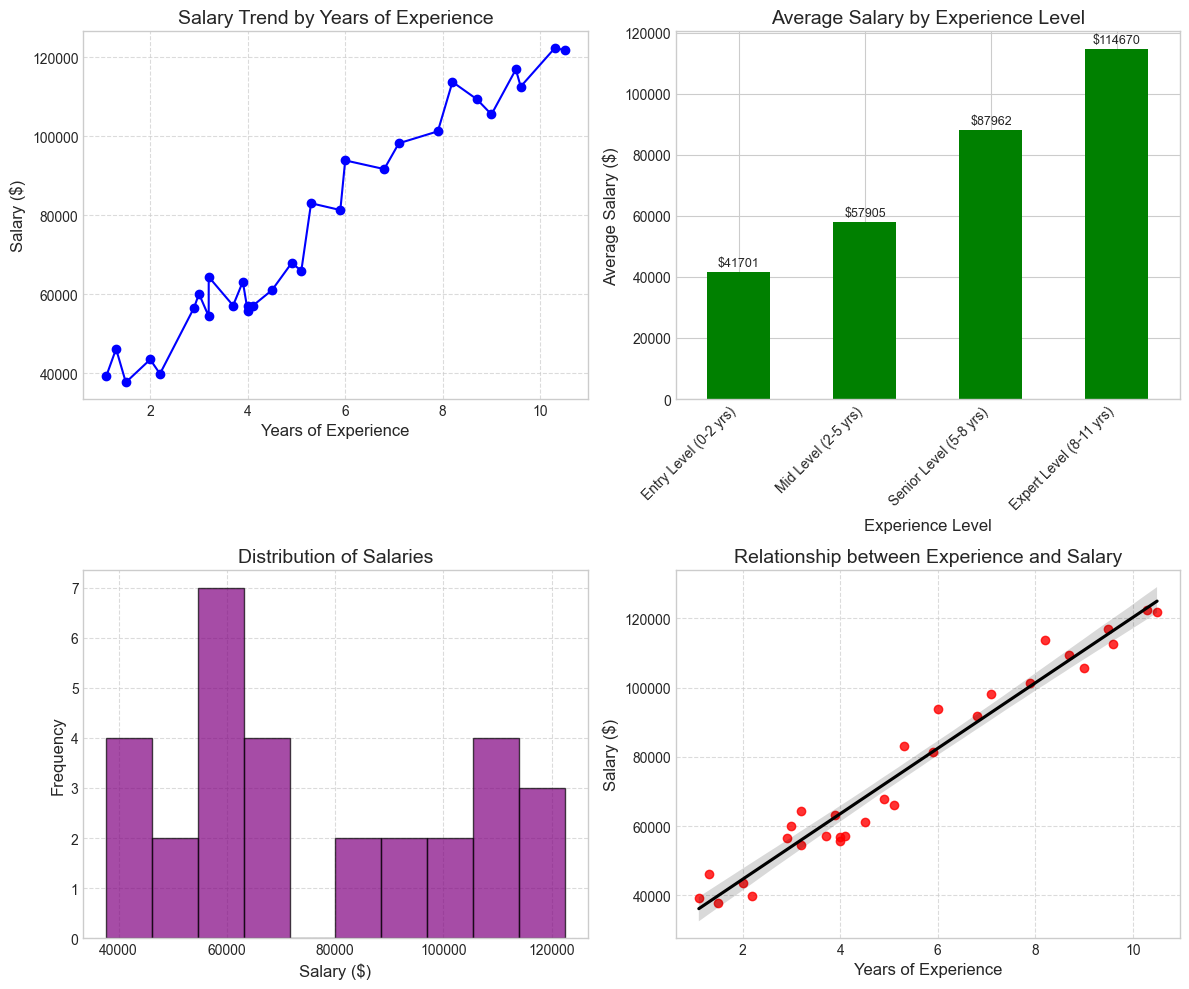

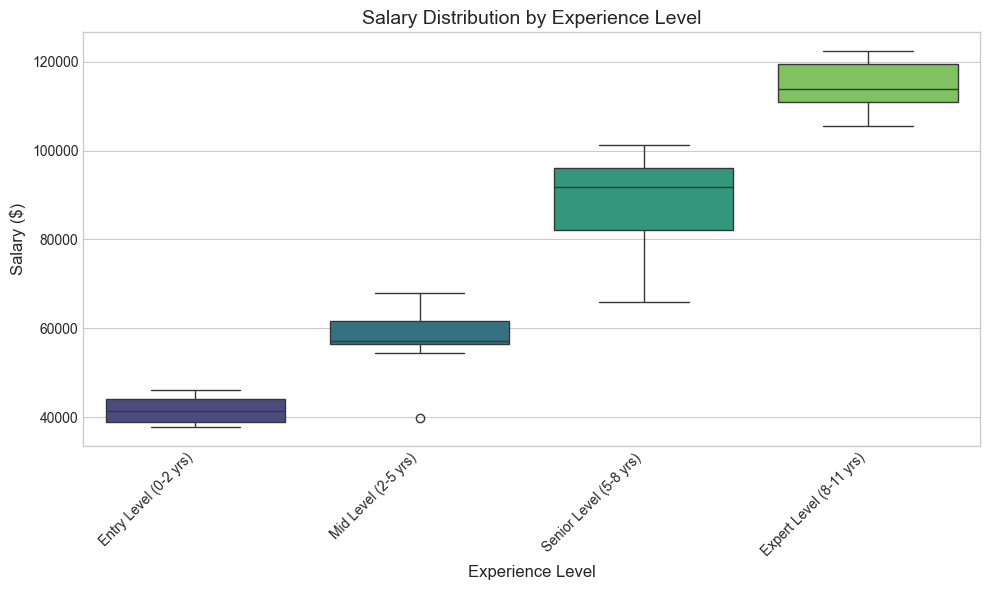

In [7]:
print("\nTask 3: Data Visualization")

# Set the figure size for all plots
plt.figure(figsize=(12, 10))

# 1. Line chart showing the trend between years of experience and salary
plt.subplot(2, 2, 1)
# Sort the data by years of experience for a better line chart
sorted_data = df.sort_values('YearsExperience')
plt.plot(sorted_data['YearsExperience'], sorted_data['Salary'], marker='o', linestyle='-', color='blue')
plt.title('Salary Trend by Years of Experience', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Bar chart showing average salary by experience level
plt.subplot(2, 2, 2)
avg_salary_by_exp = df.groupby('ExperienceLevel', observed=True)['Salary'].mean()
bars = avg_salary_by_exp.plot(kind='bar', color='green')
plt.title('Average Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Average Salary ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
# Add value labels on top of bars
for i, v in enumerate(avg_salary_by_exp):
    plt.text(i, v + 2000, f'${v:.0f}', ha='center', fontsize=9)

# 3. Histogram of salary distribution
plt.subplot(2, 2, 3)
plt.hist(df['Salary'], bins=10, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Salaries', fontsize=14)
plt.xlabel('Salary ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Scatter plot with regression line
plt.subplot(2, 2, 4)
sns.regplot(x='YearsExperience', y='Salary', data=df, scatter_kws={'color': 'red'}, line_kws={'color': 'black'})
plt.title('Relationship between Experience and Salary', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('salary_analysis_visualizations.png', dpi=300)

# Additional visualization: Box plot of salary by experience level
plt.figure(figsize=(10, 6))
sns.boxplot(x='ExperienceLevel', y='Salary', data=df, hue='ExperienceLevel', palette='viridis', legend=False)
plt.title('Salary Distribution by Experience Level', fontsize=14)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('salary_boxplot.png', dpi=300)

# Final findings and observations
print("\nKey Findings and Observations:")
print("1. There is a strong positive correlation between years of experience and salary (r = {:.4f}).".format(correlation))
print(f"2. The average salary increase per year of experience is approximately ${avg_increase_per_year:.2f}.")
print("3. The salary range is from ${:,.2f} to ${:,.2f}.".format(df['Salary'].min(), df['Salary'].max()))
print("4. Experience levels show clear salary differentiation, with Expert Level professionals earning about {:.1f}x more than Entry Level.".format(
    grouped_stats['mean'].iloc[3] / grouped_stats['mean'].iloc[0]))
print("5. The salary distribution appears to follow a relatively normal distribution with some right skewness.")

# Show all plots
plt.show()